In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# valuesx = [5,7,8,7,2,17,1,9,4,11,12,9,6]
# valuesy = [10,6,1,9,11,6,2,6,12,7,4,8,9]

# plt.ylabel('Y Axis Label')
# plt.xlabel('X Axis Label')
# plt.scatter(valuesx, valuesy)
# plt.show()

In [3]:
ImageNumber = 1

In [4]:
#image = cv2.imread("C:/Users/DELL1/Pictures/basicPlot.png")
# image = cv2.imread("C:/Users/DELL1/Pictures/basicPlotBars.png")
#image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Bar/Master.jpg")
#image = cv2.imread("C:/College/Sem 08/Major Project/Graphs/Scatter/scatterPlot.png")
image = cv2.imread(f'c:\\College\\Sem 08\\Major Project\\Graphs\\Scatter\\Testing\\testImages\\{ImageNumber}\\{ImageNumber}.png')

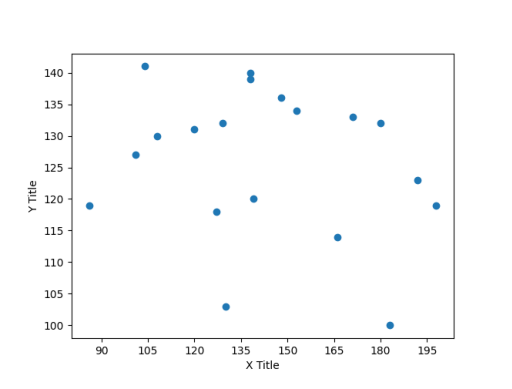

In [5]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [6]:
ab = 7
bc = 7

In [7]:
height, width, channels = image.shape
height_part = height//ab
width_part = width//bc

In [8]:
first_verti = image[:, :width_part]
last_hori = image[-height_part:, :]

In [9]:
cv2.imshow('First Vertical Strip', first_verti)
cv2.imshow('Last Horiontal Strip', last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

In [10]:
grey_first_verti = cv2.cvtColor(first_verti, cv2.COLOR_BGR2GRAY)
grey_last_hori = cv2.cvtColor(last_hori, cv2.COLOR_BGR2GRAY)

cv2.imshow('Grey Scale Strip Verti', grey_first_verti)
cv2.imshow('Grey Scale Strip Horiz', grey_last_hori)

cv2.waitKey(0)
cv2.destroyAllWindows()

X-Axis

In [11]:
import keras_ocr

pipeline = keras_ocr.pipeline.Pipeline()

images = [keras_ocr.tools.read(last_hori)]

predictions = pipeline.recognize(images)

imageWithBoxKeras = last_hori.copy()

for prediction in predictions[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKeras, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKeras)
cv2.waitKey(0)
cv2.destroyAllWindows() 

Looking for C:\Users\DELL1\.keras-ocr\craft_mlt_25k.h5
Instructions for updating:
Use `tf.image.resize(...method=ResizeMethod.BILINEAR...)` instead.
Looking for C:\Users\DELL1\.keras-ocr\crnn_kurapan.h5
1/1 [==============================] - 3s 3s/step


In [12]:
import pandas as pd

def predictions_to_dataframe(predictions):
    data_for_df = []
    
    for prediction in predictions[0]:  
        text, box = prediction
        x_center = (box[:, 0].min() + box[:, 0].max()) / 2
        y_center = (box[:, 1].min() + box[:, 1].max()) / 2
        box_width = box[:, 0].max() - box[:, 0].min()
        box_height = box[:, 1].max() - box[:, 1].min()
        box = box
        data_for_df.append({
            'text': text,
            'x_center': x_center, 
            'y_center': y_center, 
            'box_height': box_height, 
            'box_width': box_width,
            'box': box
        })
    
    return pd.DataFrame(data_for_df)

In [13]:
df = predictions_to_dataframe(predictions)
df

,text,x_center,y_center,box_height,box_width,box
0,se,53.5,2.5,5.0,15.0,"[[46.0, 0.0], [61.0, 0.0], [61.0, 5.0], [46.0,..."
1,e,65.5,2.5,5.0,7.0,"[[62.0, 0.0], [69.0, 0.0], [69.0, 5.0], [62.0,..."
2,90,120.0,31.5,13.0,18.0,"[[111.0, 25.0], [129.0, 25.0], [129.0, 38.0], ..."
3,105,179.0,31.5,13.0,26.0,"[[166.0, 25.0], [192.0, 25.0], [192.0, 38.0], ..."
4,120,240.5,31.5,13.0,27.0,"[[227.0, 25.0], [254.0, 25.0], [254.0, 38.0], ..."
5,155,300.0,31.5,13.0,26.0,"[[287.0, 25.0], [313.0, 25.0], [313.0, 38.0], ..."
6,150,361.5,31.5,13.0,27.0,"[[348.0, 25.0], [375.0, 25.0], [375.0, 38.0], ..."
7,165,421.5,31.5,13.0,27.0,"[[408.0, 25.0], [435.0, 25.0], [435.0, 38.0], ..."
8,180,481.5,31.5,13.0,27.0,"[[468.0, 25.0], [495.0, 25.0], [495.0, 38.0], ..."
9,195,542.5,31.5,13.0,27.0,"[[529.0, 25.0], [556.0, 25.0], [556.0, 38.0], ..."


X-Axis Label

In [14]:
yMax = df['y_center'].mode()[0]
yMax

31.5

In [15]:
x_label = df[(df['y_center'] >= (yMax - 5)) & (df['y_center'] <= (yMax + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_label = x_label[x_label['text'].str.isdigit()]
x_label['text'] = x_label['text'].astype(float)
x_label

,text,x_center,y_center,box_height,box_width,box
0,90.0,120.0,31.5,13.0,18.0,"[[111.0, 25.0], [129.0, 25.0], [129.0, 38.0], ..."
1,105.0,179.0,31.5,13.0,26.0,"[[166.0, 25.0], [192.0, 25.0], [192.0, 38.0], ..."
2,120.0,240.5,31.5,13.0,27.0,"[[227.0, 25.0], [254.0, 25.0], [254.0, 38.0], ..."
3,155.0,300.0,31.5,13.0,26.0,"[[287.0, 25.0], [313.0, 25.0], [313.0, 38.0], ..."
4,150.0,361.5,31.5,13.0,27.0,"[[348.0, 25.0], [375.0, 25.0], [375.0, 38.0], ..."
5,165.0,421.5,31.5,13.0,27.0,"[[408.0, 25.0], [435.0, 25.0], [435.0, 38.0], ..."
6,180.0,481.5,31.5,13.0,27.0,"[[468.0, 25.0], [495.0, 25.0], [495.0, 38.0], ..."
7,195.0,542.5,31.5,13.0,27.0,"[[529.0, 25.0], [556.0, 25.0], [556.0, 38.0], ..."


In [16]:
x_label['diff'] = (x_label['text'].diff(periods=-1).abs())
x_label['pdiff'] = (x_label['x_center'].diff(periods=-1).abs())
x_label['vpp'] = (x_label['text'].diff(periods=-1).abs())/x_label['x_center'].diff(periods=-1).abs()
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,90.0,120.0,31.5,13.0,18.0,"[[111.0, 25.0], [129.0, 25.0], [129.0, 38.0], ...",15.0,59.0,0.254237
1,105.0,179.0,31.5,13.0,26.0,"[[166.0, 25.0], [192.0, 25.0], [192.0, 38.0], ...",15.0,61.5,0.243902
2,120.0,240.5,31.5,13.0,27.0,"[[227.0, 25.0], [254.0, 25.0], [254.0, 38.0], ...",35.0,59.5,0.588235
3,155.0,300.0,31.5,13.0,26.0,"[[287.0, 25.0], [313.0, 25.0], [313.0, 38.0], ...",5.0,61.5,0.081301
4,150.0,361.5,31.5,13.0,27.0,"[[348.0, 25.0], [375.0, 25.0], [375.0, 38.0], ...",15.0,60.0,0.250000
5,165.0,421.5,31.5,13.0,27.0,"[[408.0, 25.0], [435.0, 25.0], [435.0, 38.0], ...",15.0,60.0,0.250000
6,180.0,481.5,31.5,13.0,27.0,"[[468.0, 25.0], [495.0, 25.0], [495.0, 38.0], ...",15.0,61.0,0.245902
7,195.0,542.5,31.5,13.0,27.0,"[[529.0, 25.0], [556.0, 25.0], [556.0, 38.0], ...",NaN,NaN,NaN


In [17]:
most_common_diff_x = x_label['diff'][:-1].mode()[0]
most_common_diff_x

15.0

In [18]:
x_label['roundedVPP'] = x_label['vpp'].round(2)
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,120.0,31.5,13.0,18.0,"[[111.0, 25.0], [129.0, 25.0], [129.0, 38.0], ...",15.0,59.0,0.254237,0.25
1,105.0,179.0,31.5,13.0,26.0,"[[166.0, 25.0], [192.0, 25.0], [192.0, 38.0], ...",15.0,61.5,0.243902,0.24
2,120.0,240.5,31.5,13.0,27.0,"[[227.0, 25.0], [254.0, 25.0], [254.0, 38.0], ...",35.0,59.5,0.588235,0.59
3,155.0,300.0,31.5,13.0,26.0,"[[287.0, 25.0], [313.0, 25.0], [313.0, 38.0], ...",5.0,61.5,0.081301,0.08
4,150.0,361.5,31.5,13.0,27.0,"[[348.0, 25.0], [375.0, 25.0], [375.0, 38.0], ...",15.0,60.0,0.250000,0.25
5,165.0,421.5,31.5,13.0,27.0,"[[408.0, 25.0], [435.0, 25.0], [435.0, 38.0], ...",15.0,60.0,0.250000,0.25
6,180.0,481.5,31.5,13.0,27.0,"[[468.0, 25.0], [495.0, 25.0], [495.0, 38.0], ...",15.0,61.0,0.245902,0.25
7,195.0,542.5,31.5,13.0,27.0,"[[529.0, 25.0], [556.0, 25.0], [556.0, 38.0], ...",NaN,NaN,NaN,NaN


In [19]:
mostCommonValue_x = x_label['roundedVPP'].value_counts().idxmax()
mostCommonIndex_x = x_label[x_label['roundedVPP'] == mostCommonValue_x].index[0]
mostCommonIndex_x

0

In [20]:
most_common_vpp_x = x_label['vpp'].iloc[mostCommonIndex_x]
# most_common_vpp_x = x_label['vpp'][:-1].mode()[0]

# if most_common_vpp_x == 0:
#     frequency_x = x_label['vpp'].value_counts()

#     if len(frequency_x) > 1:
#         most_common_vpp_x = frequency_x.index[1] 

most_common_vpp_x

0.2542372881355932

In [21]:
inRange_x = x_label['vpp'].between(most_common_vpp_x - 0.05, most_common_vpp_x + 0.05)

x_label = x_label[inRange_x | (x_label.index == x_label.index[-1])]
#x_label = x_label.drop(columns=['diff'])

x_label.reset_index(drop=True, inplace=True)
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,120.0,31.5,13.0,18.0,"[[111.0, 25.0], [129.0, 25.0], [129.0, 38.0], ...",15.0,59.0,0.254237,0.25
1,105.0,179.0,31.5,13.0,26.0,"[[166.0, 25.0], [192.0, 25.0], [192.0, 38.0], ...",15.0,61.5,0.243902,0.24
2,150.0,361.5,31.5,13.0,27.0,"[[348.0, 25.0], [375.0, 25.0], [375.0, 38.0], ...",15.0,60.0,0.250000,0.25
3,165.0,421.5,31.5,13.0,27.0,"[[408.0, 25.0], [435.0, 25.0], [435.0, 38.0], ...",15.0,60.0,0.250000,0.25
4,180.0,481.5,31.5,13.0,27.0,"[[468.0, 25.0], [495.0, 25.0], [495.0, 38.0], ...",15.0,61.0,0.245902,0.25
5,195.0,542.5,31.5,13.0,27.0,"[[529.0, 25.0], [556.0, 25.0], [556.0, 38.0], ...",NaN,NaN,NaN,NaN


In [22]:
indexToDrop_x  = []
iii_x = 0
jjj_x = 1

if (x_label['diff'].iloc[0] != most_common_diff_x) or (most_common_vpp_x - 0.05 <= x_label['diff'].iloc[0] <= most_common_vpp_x + 0.05):
    indexToDrop_x.append(0)
    iii_x = jjj_x
    jjj_x += 1

In [23]:
while jjj_x != (len(x_label)):
    kkk_x = x_label['text'][iii_x] - x_label['text'][jjj_x]
    
    if kkk_x < 0:
       iii_x = jjj_x
       jjj_x += 1
    else:
        indexToDrop_x.append(jjj_x)
        jjj_x+=1
    
indexToDrop_x

[]

In [24]:
for i in range(len(x_label)):
    if i in indexToDrop_x:
        x_label.drop(index=i, inplace=True)
        
x_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,120.0,31.5,13.0,18.0,"[[111.0, 25.0], [129.0, 25.0], [129.0, 38.0], ...",15.0,59.0,0.254237,0.25
1,105.0,179.0,31.5,13.0,26.0,"[[166.0, 25.0], [192.0, 25.0], [192.0, 38.0], ...",15.0,61.5,0.243902,0.24
2,150.0,361.5,31.5,13.0,27.0,"[[348.0, 25.0], [375.0, 25.0], [375.0, 38.0], ...",15.0,60.0,0.250000,0.25
3,165.0,421.5,31.5,13.0,27.0,"[[408.0, 25.0], [435.0, 25.0], [435.0, 38.0], ...",15.0,60.0,0.250000,0.25
4,180.0,481.5,31.5,13.0,27.0,"[[468.0, 25.0], [495.0, 25.0], [495.0, 38.0], ...",15.0,61.0,0.245902,0.25
5,195.0,542.5,31.5,13.0,27.0,"[[529.0, 25.0], [556.0, 25.0], [556.0, 38.0], ...",NaN,NaN,NaN,NaN


X-Axis Title

In [25]:
x_title = df[df['y_center'] > (yMax + 5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,x,311.5,50.5,13.0,13.0,"[[305.0, 44.0], [318.0, 44.0], [318.0, 57.0], ..."
1,title,335.0,50.5,13.0,32.0,"[[319.0, 44.0], [351.0, 44.0], [351.0, 57.0], ..."


In [26]:
yMax1 = x_title['y_center'].mode()[0]
yMax1

50.5

In [27]:
x_title = x_title[(x_title['y_center'] >= (yMax1 - 5)) & (x_title['y_center'] <= (yMax1 + 5))].sort_values(by='x_center', ascending=True).reset_index(drop=True)
x_title

,text,x_center,y_center,box_height,box_width,box
0,x,311.5,50.5,13.0,13.0,"[[305.0, 44.0], [318.0, 44.0], [318.0, 57.0], ..."
1,title,335.0,50.5,13.0,32.0,"[[319.0, 44.0], [351.0, 44.0], [351.0, 57.0], ..."


In [28]:
xtitle = ''

for indx in x_title.index:
    xtitle += x_title['text'][indx] + ' '
        
xtitle = xtitle.strip()
xtitle

'x title'

X-Axis Detection

In [29]:
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=int)
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=int)

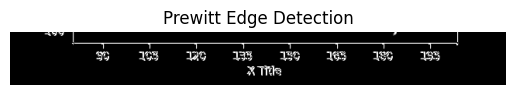

In [30]:
img_prewittx = cv2.filter2D(grey_last_hori, -1, kernelx)
img_prewitty = cv2.filter2D(grey_last_hori, -1, kernely)

img_prewitt = img_prewittx + img_prewitty

plt.imshow(img_prewitt, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

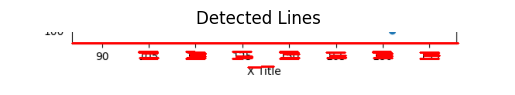

In [31]:
linesInLastHori = last_hori.copy()

_, binary_prewitt = cv2.threshold(img_prewitt, 50, 255, cv2.THRESH_BINARY)
linesP = cv2.HoughLinesP(binary_prewitt, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInLastHori, (x1, y1), (x2, y2), (0, 0, 255), 2)
    
linesInLastHori = cv2.cvtColor(linesInLastHori, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

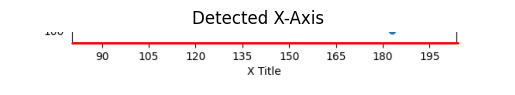

In [32]:
xAxisDetected = last_hori.copy()

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        if y1 < yMax and y2 < yMax:
            cv2.line(xAxisDetected, (x1, y1), (x2, y2), (0, 0, 255), 2)
            break
        
xAxisDetected = cv2.cvtColor(xAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(xAxisDetected )
plt.title('Detected X-Axis')
plt.axis('off')
plt.show()

In [33]:
xAxisCordsInStrip = [[x1, y1], [x2, y2]]
xAxisCordsInStrip = sorted(xAxisCordsInStrip, key=lambda x: x[0])
xAxisCordsInStrip

[[80, 14], [578, 14]]

In [34]:
original_height_part = height - height_part

xAxisCords = [[xAxisCordsInStrip[0][0], xAxisCordsInStrip[0][1] + original_height_part], [xAxisCordsInStrip[1][0], xAxisCordsInStrip[1][1] + original_height_part]]
xAxisCords

[[80, 426], [578, 426]]

In [35]:
xAxisCord = 0

for i in xAxisCords:
    xAxisCord+=i[1]
    
xAxisCord = xAxisCord/2
xAxisCord

426.0

In [36]:
x_label_copy = x_label.copy()

for index, row in x_label_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_label_copy.at[index, 'box'] = arr

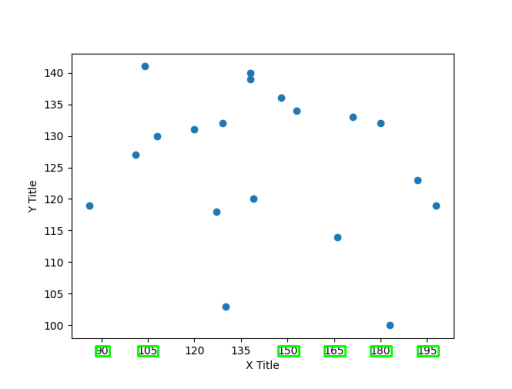

In [37]:
image11 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image1223 = image11.copy()

for indx in x_label_copy.index:
    box = x_label_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [38]:
x_title_copy = x_title.copy()

for index, row in x_title_copy.iterrows():
    arr = row['box']
    arr[:, 1] += original_height_part
    x_title_copy.at[index, 'box'] = arr

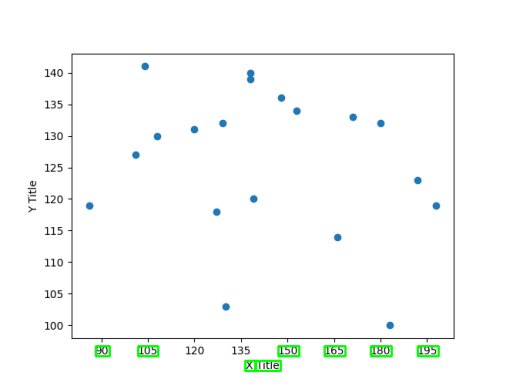

In [39]:
for indx in x_title_copy.index:
    box = x_title_copy['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

Chceck for Equal Pixel Distribution: X-Axis

In [40]:
if len(x_label) == 1:
    most_common_pdiff_x = x_label['pdiff'][:].mode()[0]
else:
    most_common_pdiff_x = x_label['pdiff'][:-1].mode()[0]
most_common_pdiff_x

60.0

In [41]:
x_label[:1]

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,90.0,120.0,31.5,13.0,18.0,"[[111.0, 437.0], [129.0, 437.0], [129.0, 450.0...",15.0,59.0,0.254237,0.25


Y-Axis

In [42]:
images = [keras_ocr.tools.read(first_verti)]

predictions1 = pipeline.recognize(images)

imageWithBoxKerasVerti = first_verti.copy()

for prediction in predictions1[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasVerti, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasVerti)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 1s/step


Y-Axis Labels

In [43]:
df1 = predictions_to_dataframe(predictions1)
df1

,text,x_center,y_center,box_height,box_width,box
0,140,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45..."
1,155,58.5,124.5,13.0,27.0,"[[45.0, 118.0], [72.0, 118.0], [72.0, 131.0], ..."
2,150,58.5,165.5,13.0,27.0,"[[45.0, 159.0], [72.0, 159.0], [72.0, 172.0], ..."
3,125,58.5,206.5,13.0,27.0,"[[45.0, 200.0], [72.0, 200.0], [72.0, 213.0], ..."
4,s,29.5,243.5,43.0,13.0,"[[23.0, 222.0], [36.0, 222.0], [36.0, 265.0], ..."
5,120,58.5,247.5,13.0,27.0,"[[45.0, 241.0], [72.0, 241.0], [72.0, 254.0], ..."
6,115,58.5,288.5,13.0,27.0,"[[45.0, 282.0], [72.0, 282.0], [72.0, 295.0], ..."
7,110,58.5,329.5,13.0,27.0,"[[45.0, 323.0], [72.0, 323.0], [72.0, 336.0], ..."
8,105,58.5,370.5,13.0,27.0,"[[45.0, 364.0], [72.0, 364.0], [72.0, 377.0], ..."
9,100,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ..."


In [44]:
df11 = df1.copy()
df11 = df11[df11['text'].str.isdigit()]
df11['text'] = df11['text'].astype(float)
df11

,text,x_center,y_center,box_height,box_width,box
0,140.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45..."
1,155.0,58.5,124.5,13.0,27.0,"[[45.0, 118.0], [72.0, 118.0], [72.0, 131.0], ..."
2,150.0,58.5,165.5,13.0,27.0,"[[45.0, 159.0], [72.0, 159.0], [72.0, 172.0], ..."
3,125.0,58.5,206.5,13.0,27.0,"[[45.0, 200.0], [72.0, 200.0], [72.0, 213.0], ..."
5,120.0,58.5,247.5,13.0,27.0,"[[45.0, 241.0], [72.0, 241.0], [72.0, 254.0], ..."
6,115.0,58.5,288.5,13.0,27.0,"[[45.0, 282.0], [72.0, 282.0], [72.0, 295.0], ..."
7,110.0,58.5,329.5,13.0,27.0,"[[45.0, 323.0], [72.0, 323.0], [72.0, 336.0], ..."
8,105.0,58.5,370.5,13.0,27.0,"[[45.0, 364.0], [72.0, 364.0], [72.0, 377.0], ..."
9,100.0,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ..."


In [45]:
xMax = df11['x_center'].mode()[0]
xMax

58.5

In [46]:
y_label = df11[(df11['x_center'] >= (xMax - 5)) & (df11['x_center'] <= (xMax + 5))].sort_values(by='y_center', ascending=True).reset_index(drop=True)
y_label

,text,x_center,y_center,box_height,box_width,box
0,140.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45..."
1,155.0,58.5,124.5,13.0,27.0,"[[45.0, 118.0], [72.0, 118.0], [72.0, 131.0], ..."
2,150.0,58.5,165.5,13.0,27.0,"[[45.0, 159.0], [72.0, 159.0], [72.0, 172.0], ..."
3,125.0,58.5,206.5,13.0,27.0,"[[45.0, 200.0], [72.0, 200.0], [72.0, 213.0], ..."
4,120.0,58.5,247.5,13.0,27.0,"[[45.0, 241.0], [72.0, 241.0], [72.0, 254.0], ..."
5,115.0,58.5,288.5,13.0,27.0,"[[45.0, 282.0], [72.0, 282.0], [72.0, 295.0], ..."
6,110.0,58.5,329.5,13.0,27.0,"[[45.0, 323.0], [72.0, 323.0], [72.0, 336.0], ..."
7,105.0,58.5,370.5,13.0,27.0,"[[45.0, 364.0], [72.0, 364.0], [72.0, 377.0], ..."
8,100.0,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ..."


In [47]:
y_label['diff'] = (y_label['text'].diff(periods=-1).abs())
y_label['pdiff'] = (y_label['y_center'].diff(periods=-1).abs())
y_label['vpp'] = (y_label['text'].diff(periods=-1).abs())/y_label['y_center'].diff(periods=-1).abs()
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp
0,140.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45...",15.0,41.0,0.365854
1,155.0,58.5,124.5,13.0,27.0,"[[45.0, 118.0], [72.0, 118.0], [72.0, 131.0], ...",5.0,41.0,0.121951
2,150.0,58.5,165.5,13.0,27.0,"[[45.0, 159.0], [72.0, 159.0], [72.0, 172.0], ...",25.0,41.0,0.609756
3,125.0,58.5,206.5,13.0,27.0,"[[45.0, 200.0], [72.0, 200.0], [72.0, 213.0], ...",5.0,41.0,0.121951
4,120.0,58.5,247.5,13.0,27.0,"[[45.0, 241.0], [72.0, 241.0], [72.0, 254.0], ...",5.0,41.0,0.121951
5,115.0,58.5,288.5,13.0,27.0,"[[45.0, 282.0], [72.0, 282.0], [72.0, 295.0], ...",5.0,41.0,0.121951
6,110.0,58.5,329.5,13.0,27.0,"[[45.0, 323.0], [72.0, 323.0], [72.0, 336.0], ...",5.0,41.0,0.121951
7,105.0,58.5,370.5,13.0,27.0,"[[45.0, 364.0], [72.0, 364.0], [72.0, 377.0], ...",5.0,41.0,0.121951
8,100.0,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ...",NaN,NaN,NaN


In [48]:
most_common_diff_y = y_label['diff'][:-1].mode()[0]
most_common_diff_y

5.0

In [49]:
y_label['roundedVPP'] = y_label['vpp'].round(2)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,140.0,58.5,83.5,13.0,27.0,"[[45.0, 77.0], [72.0, 77.0], [72.0, 90.0], [45...",15.0,41.0,0.365854,0.37
1,155.0,58.5,124.5,13.0,27.0,"[[45.0, 118.0], [72.0, 118.0], [72.0, 131.0], ...",5.0,41.0,0.121951,0.12
2,150.0,58.5,165.5,13.0,27.0,"[[45.0, 159.0], [72.0, 159.0], [72.0, 172.0], ...",25.0,41.0,0.609756,0.61
3,125.0,58.5,206.5,13.0,27.0,"[[45.0, 200.0], [72.0, 200.0], [72.0, 213.0], ...",5.0,41.0,0.121951,0.12
4,120.0,58.5,247.5,13.0,27.0,"[[45.0, 241.0], [72.0, 241.0], [72.0, 254.0], ...",5.0,41.0,0.121951,0.12
5,115.0,58.5,288.5,13.0,27.0,"[[45.0, 282.0], [72.0, 282.0], [72.0, 295.0], ...",5.0,41.0,0.121951,0.12
6,110.0,58.5,329.5,13.0,27.0,"[[45.0, 323.0], [72.0, 323.0], [72.0, 336.0], ...",5.0,41.0,0.121951,0.12
7,105.0,58.5,370.5,13.0,27.0,"[[45.0, 364.0], [72.0, 364.0], [72.0, 377.0], ...",5.0,41.0,0.121951,0.12
8,100.0,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ...",NaN,NaN,NaN,NaN


In [50]:
mostCommonValue_y = y_label['roundedVPP'].value_counts().idxmax()
mostCommonIndex_y = y_label[y_label['roundedVPP'] == mostCommonValue_y].index[0]
mostCommonIndex_y

1

In [51]:
most_common_vpp_y = y_label['vpp'].iloc[mostCommonIndex_y]

# if most_common_vpp_y == 0:
#     frequency_y = y_label['vpp'].value_counts()

#     if len(frequency_y) > 1:
#         most_common_vpp = frequency_y.index[1] 

most_common_vpp_y

0.12195121951219512

In [52]:
inRange = y_label['vpp'].between(most_common_vpp_y - 0.05, most_common_vpp_y + 0.05)

y_label = y_label[inRange | (y_label.index == y_label.index[-1])]
#y_label = y_label.drop(columns=['diff'])

y_label.reset_index(drop=True, inplace=True)
y_label

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
0,155.0,58.5,124.5,13.0,27.0,"[[45.0, 118.0], [72.0, 118.0], [72.0, 131.0], ...",5.0,41.0,0.121951,0.12
1,125.0,58.5,206.5,13.0,27.0,"[[45.0, 200.0], [72.0, 200.0], [72.0, 213.0], ...",5.0,41.0,0.121951,0.12
2,120.0,58.5,247.5,13.0,27.0,"[[45.0, 241.0], [72.0, 241.0], [72.0, 254.0], ...",5.0,41.0,0.121951,0.12
3,115.0,58.5,288.5,13.0,27.0,"[[45.0, 282.0], [72.0, 282.0], [72.0, 295.0], ...",5.0,41.0,0.121951,0.12
4,110.0,58.5,329.5,13.0,27.0,"[[45.0, 323.0], [72.0, 323.0], [72.0, 336.0], ...",5.0,41.0,0.121951,0.12
5,105.0,58.5,370.5,13.0,27.0,"[[45.0, 364.0], [72.0, 364.0], [72.0, 377.0], ...",5.0,41.0,0.121951,0.12
6,100.0,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ...",NaN,NaN,NaN,NaN


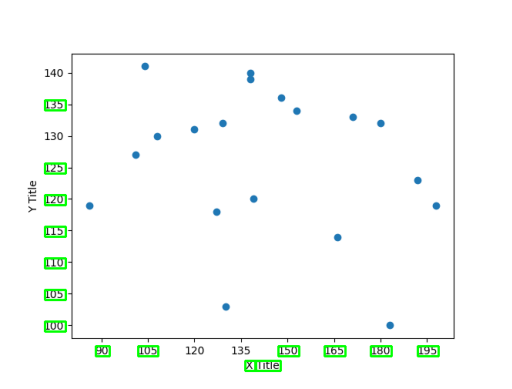

In [53]:
for indx in y_label.index:
    box = y_label['box'][indx]
    box = box.astype(int)
    cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

Chceck for Equal Pixel Distribution

In [54]:
most_common_pdiff_y = y_label['pdiff'][:-1].mode()[0]
most_common_pdiff_y

41.0

In [55]:
y_label[-1:]

,text,x_center,y_center,box_height,box_width,box,diff,pdiff,vpp,roundedVPP
6,100.0,58.5,411.5,13.0,27.0,"[[45.0, 405.0], [72.0, 405.0], [72.0, 418.0], ...",NaN,NaN,NaN,NaN


In [56]:
corVal_y = y_label['text'].iloc[-1]
corFir = y_label['y_center'].iloc[-1]
betweenFirst = xAxisCord - corFir

print(betweenFirst)

14.5


In [57]:
import math

corVal = y_label['text'].iloc[-1]
corFir = y_label['y_center'].iloc[-1]
betweenFirst = xAxisCord - corFir

if corVal == most_common_diff:
    if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
        # Case-1
        toAdd = 0
        fromCal = xAxisCord
    else:
        # Case-5
        toAdd = corVal
        fromCal = corFir
else:
    if (betweenFirst > most_common_pdiff - 5) and (betweenFirst < most_common_pdiff + 5):
        #Case-3
        toAdd = corVal - most_common_diff
        fromCal = xAxisCord
    elif (betweenFirst < most_common_pdiff - 5):
        #Case-7
        toAdd = corVal
        fromCal = corFir
    else:   
        dif = betweenFirst/most_common_pdiff

        if dif - math.floor(dif) > 0.9:
            dif = math.ceil(dif)
        else:
            dif = math.floor(dif)

        if dif == 1:
            newCorVal = corVal - most_common_diff
            newCorFir = corFir - most_common_pdiff
            newBetweenFirst = xAxisCord - newCorFir
        else:   
            newCorVal = corVal - (dif-1)*most_common_diff
            newCorFir = corFir - (dif-1)*most_common_pdiff
            newBetweenFirst = xAxisCord - newCorFir


        if newCorVal == most_common_diff:
            if (newBetweenFirst > most_common_pdiff - 5) and (newBetweenFirst < most_common_pdiff + 5):
                # Case-2
                toAdd = 0
                fromCal = xAxisCord
            else:
                # Case-6
                toAdd = newCorVal
                fromCal = newCorFir
        else:
            if (newBetweenFirst > most_common_pdiff - 5) and (newBetweenFirst < most_common_pdiff + 5):
                # Case-4
                toAdd = newCorVal - most_common_diff
                fromCal = xAxisCord
            else:
                # Case-8
                toAdd = newCorVal
                fromCal = newCorFir

NameError: name 'most_common_diff' is not defined

In [ ]:
# if (corFir > most_common_pdiff + 5):
#     dif = betweenFirst//most_common_pdiff
    
#     fin = abs(betweenFirst - dif*most_common_pdiff)
    
#     if fin < 5:
#         if y_label['text'].iloc[-1] == most_common_diff:
#             toAdd = 0
#             fromCal = xAxisCord
#         else:
#             toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#             fromCal = xAxisCord
#     else:
#         toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#         fromCal = xAxisCord - fin

In [ ]:
# if (corFir > most_common_pdiff + 5):
#     dif = betweenFirst//most_common_pdiff
    
#     fin = abs(betweenFirst - dif*most_common_pdiff)
    
#     if fin < 5:
#         toAdd = 0
#         fromCal = xAxisCord
#     else:
#         toAdd = y_label['text'].iloc[-1] - dif*most_common_diff
#         fromCal = xAxisCord - fin

Value Per Pixel

In [ ]:
y_label['vpp'][:-1].mean()

0.03270093366723337

In [ ]:
vpp = 0
tot = len(y_label)-1

for i in range (tot):
    vpp += abs(y_label['text'][i+1] - y_label['text'][i])/abs(y_label['y_center'][i+1] - y_label['y_center'][i])
    
vpp = vpp/tot
vpp

0.03281781071258166

Y-Axis Title

In [58]:
rotated_image = cv2.rotate(first_verti, cv2.ROTATE_90_CLOCKWISE)
rotated_image1 = cv2.rotate(first_verti, cv2.ROTATE_90_COUNTERCLOCKWISE)

cv2.imshow('90 CLOCKWISE', rotated_image)
cv2.imshow('90 COUNTERCLOCKWISE', rotated_image1)
cv2.waitKey(0)
cv2.destroyAllWindows() 

In [59]:
images = [keras_ocr.tools.read(rotated_image)]

predictions2 = pipeline.recognize(images)

imageWithBoxKerasRotateColck = rotated_image.copy()

for prediction in predictions2[0]:  
    word, box = prediction
    box = box.astype(int)
    cv2.polylines(imageWithBoxKerasRotateColck, [box], isClosed=True, color=(0, 255, 0), thickness=2)

cv2.imshow('Image with Bounding Boxes', imageWithBoxKerasRotateColck)
cv2.waitKey(0)
cv2.destroyAllWindows() 

1/1 [==============================] - 1s 986ms/step


In [60]:
df2 = predictions_to_dataframe(predictions2)
df2

,text,x_center,y_center,box_height,box_width,box
0,ytitle,237.0,29.499996,13.0,44.0,"[[215.0, 22.999996], [259.0, 22.999996], [259...."
1,g,69.5,58.000000,26.0,13.0,"[[63.0, 45.0], [76.0, 45.0], [76.0, 71.0], [63..."
2,x,110.5,58.000000,26.0,15.0,"[[103.0, 45.0], [118.0, 45.0], [118.0, 71.0], ..."
3,s,357.0,57.500000,27.0,18.0,"[[348.0, 44.0], [366.0, 44.0], [366.0, 71.0], ..."
4,s,397.0,58.000000,26.0,14.0,"[[390.0, 45.0], [404.0, 45.0], [404.0, 71.0], ..."
5,e,163.5,58.000000,26.0,41.0,"[[143.0, 45.0], [184.0, 45.0], [184.0, 71.0], ..."
6,ee,204.5,58.000000,26.0,45.0,"[[182.0, 45.0], [227.0, 45.0], [227.0, 71.0], ..."
7,e,238.5,58.000000,26.0,29.0,"[[224.0, 45.0], [253.0, 45.0], [253.0, 71.0], ..."
8,e,279.5,58.000000,26.0,29.0,"[[265.0, 45.0], [294.0, 45.0], [294.0, 71.0], ..."
9,s,320.0,58.500000,27.0,26.0,"[[307.0, 45.0], [333.0, 45.0], [333.0, 72.0], ..."


In [61]:
df2 = df2[df2['y_center'] < (xMax-5)].sort_values(by='x_center', ascending=True).reset_index(drop=True)
df2

,text,x_center,y_center,box_height,box_width,box
0,ytitle,237.0,29.499996,13.0,44.0,"[[215.0, 22.999996], [259.0, 22.999996], [259...."


In [62]:
ytitle = ''

for indx in df2.index:
    ytitle += df2['text'][indx] + ' '
        
ytitle = ytitle.strip()
ytitle

'ytitle'

In [63]:
blahblah = [2, 4, 5]

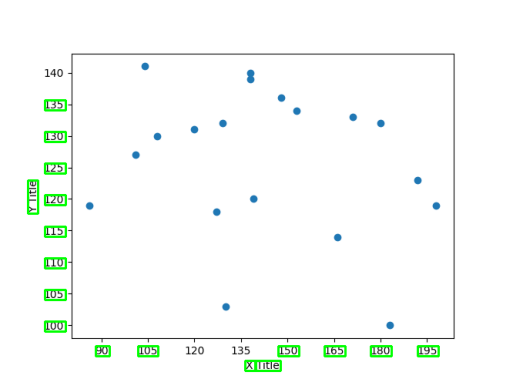

In [64]:
for indx in df1.index:
    if indx in blahblah:
        box = df1['box'][indx]
        box = box.astype(int)
        cv2.polylines(image1223, [box], isClosed=True, color=(0, 255, 0), thickness=2)
    
plt.imshow(image1223)
plt.axis('off')
plt.show() 

Y-Axis Detection

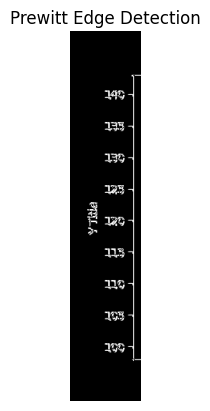

In [65]:
img_prewittx1 = cv2.filter2D(grey_first_verti, -1, kernelx)
img_prewitty1 = cv2.filter2D(grey_first_verti, -1, kernely)

img_prewitt1 = img_prewittx1 + img_prewitty1

plt.imshow(img_prewitt1, cmap='gray')
plt.title('Prewitt Edge Detection')
plt.axis('off')
plt.show()

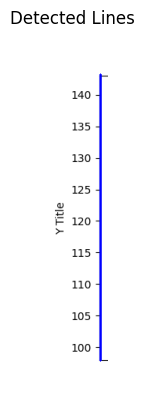

In [66]:
linesInFirstVeti = first_verti.copy()

_, binary_prewitt1 = cv2.threshold(img_prewitt1, 50, 255, cv2.THRESH_BINARY)
linesP1 = cv2.HoughLinesP(binary_prewitt1, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        cv2.line(linesInFirstVeti, (x1, y1), (x2, y2), (255, 0, 0), 2)
        print()
    
linesInLastHori = cv2.cvtColor(linesInFirstVeti, cv2.COLOR_BGR2RGB)
plt.imshow(linesInLastHori )
plt.title('Detected Lines')
plt.axis('off')
plt.show()

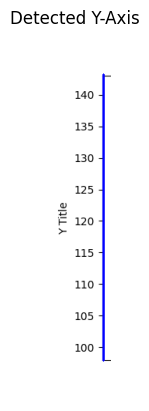

In [67]:
yAxisDetected = first_verti.copy()

if linesP1 is not None:
    for line in linesP1:
        x1, y1, x2, y2 = line[0]
        if x1 > xMax and x2 > xMax:
            cv2.line(yAxisDetected, (x1, y1), (x2, y2), (255, 0, 0), 2)
            break
        
yAxisDetected = cv2.cvtColor(yAxisDetected, cv2.COLOR_BGR2RGB)
plt.imshow(yAxisDetected )
plt.title('Detected Y-Axis')
plt.axis('off')
plt.show()

In [68]:
yAxisCords = [[x1, y1], [x2, y2]]
yAxisCords = sorted(yAxisCords, key=lambda x: x[1])
yAxisCords

[[81, 56], [81, 427]]

In [69]:
yAxisCord = 0

for i in yAxisCords:
    yAxisCord+=i[0]
    
yAxisCord = yAxisCord/2
yAxisCord

81.0

Detcted Both Axes 

In [70]:
detectedAxes = image.copy()

cv2.line(detectedAxes, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (0, 0, 255), 2)
cv2.line(detectedAxes, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (0, 255, 0), 2)

cv2.imshow('Image with Both Axes', detectedAxes)
cv2.waitKey(0)
cv2.destroyAllWindows()

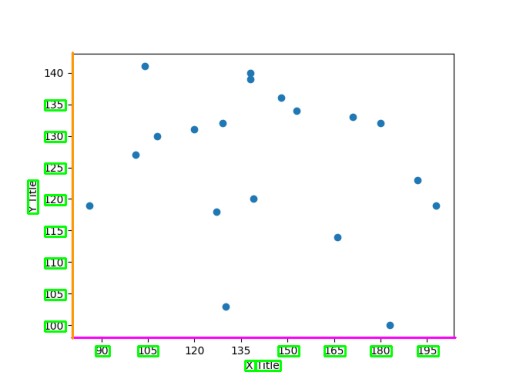

In [71]:
cv2.line(image1223, (xAxisCords[0][0], xAxisCords[0][1]), (xAxisCords[1][0], xAxisCords[1][1]), (255, 0, 255), 2)
cv2.line(image1223, (yAxisCords[0][0], yAxisCords[0][1]), (yAxisCords[1][0], yAxisCords[1][1]), (255, 150, ), 2)

plt.imshow(image1223)
plt.axis('off')
plt.show()

Color Detction

Croping Image

In [72]:
yAxisCords

[[81, 56], [81, 427]]

In [73]:
xAxisCords

[[80, 426], [578, 426]]

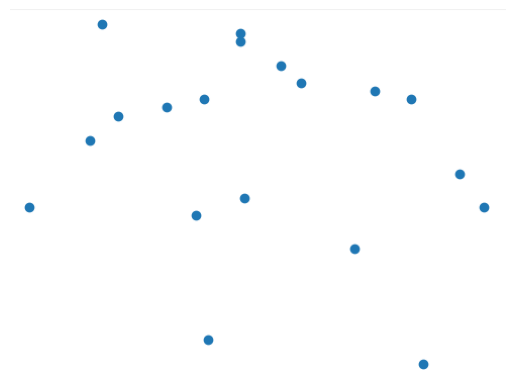

In [74]:
fropTop = yAxisCords[0][1]+3
toBottom = xAxisCords[0][1]-3

fromLeft = (yAxisCords[0][0] + yAxisCords[1][0])//2+3
toRight = xAxisCords[1][0]-3

imagePart = image[fropTop:toBottom, fromLeft:toRight]

plt.imshow(cv2.cvtColor(imagePart, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
# cv2.imshow('part', imagePart)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

Color Detection

In [75]:
imagePart1 = cv2.cvtColor(imagePart, cv2.COLOR_BGR2RGB)

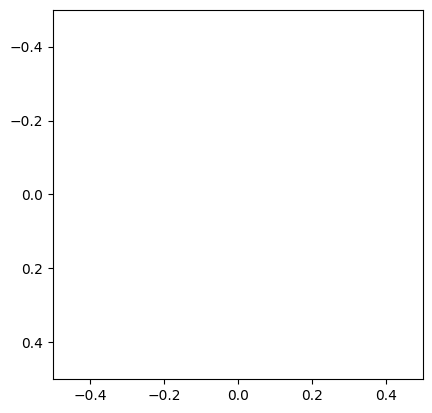

[255.62445 255.62494 255.62631]


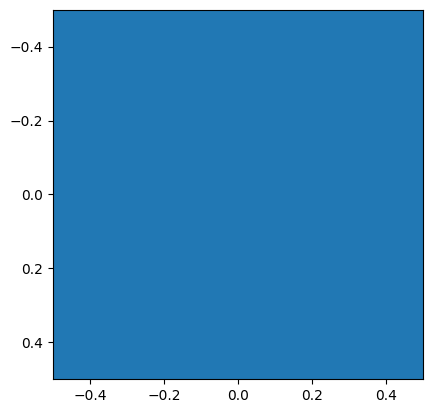

[ 33.980858 120.701385 180.90659 ]


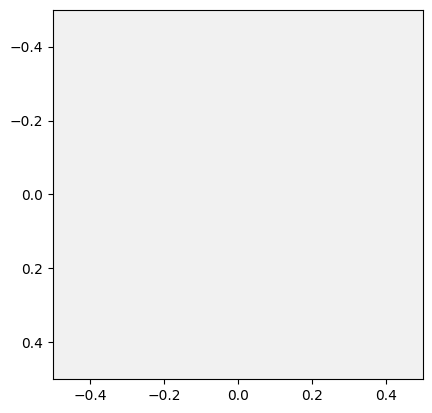

[241.00002 241.00002 241.00002]


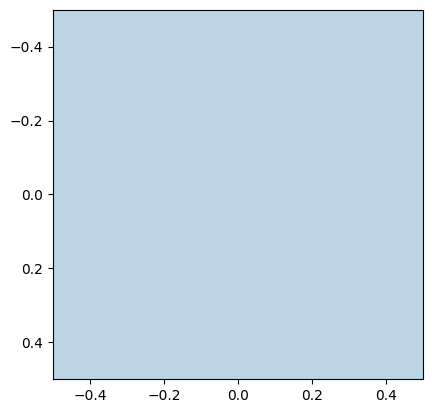

[187.31183 213.62366 231.89784]


In [76]:
pixels = imagePart1.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 4

_, labels, centers = cv2.kmeans(pixels, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

unique, counts = np.unique(labels, return_counts=True)

sorted_colors = sorted(zip(counts, centers), key=lambda x: x[0], reverse=True)

sorted_colors = [tpl[1] for tpl in sorted_colors]

for color in sorted_colors:
    plt.imshow([[color.astype(np.uint8)/255]])
    plt.show()
    print(color)

In [77]:
modified_image = np.copy(imagePart1)

# Assign white color to pixels belonging to the 2nd cluster and black color to pixels belonging to other clusters
for idx, color in enumerate(centers):
    if idx == 1:  # Assuming the 2nd cluster (index starts from 0)
        mask = (labels == idx).reshape(imagePart1.shape[:2])
        modified_image[mask] = [255, 255, 255]  # White color
    else:
        mask = (labels == idx).reshape(imagePart1.shape[:2])
        modified_image[mask] = [0, 0, 0]  # Black color

cv2.imshow('Original Image', cv2.cvtColor(imagePart1, cv2.COLOR_BGR2RGB))
cv2.imshow('Modified Image', modified_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

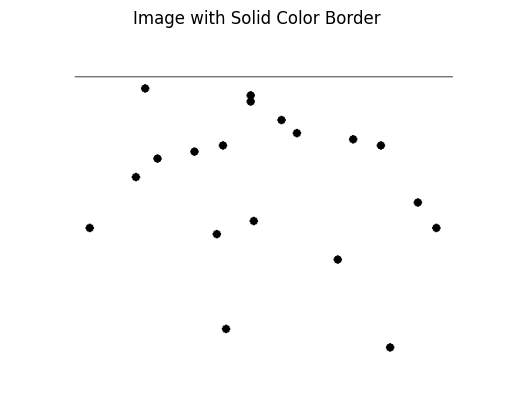

In [78]:
# Define the color for the border, here we use black
border_color = [255, 255, 255]

image_with_border = cv2.copyMakeBorder(modified_image, fropTop, (height - toBottom), fromLeft, (width - toRight), cv2.BORDER_CONSTANT, value=border_color)

plt.imshow(cv2.cvtColor(image_with_border, cv2.COLOR_BGR2RGB))
plt.title("Image with Solid Color Border")
plt.axis('off')
plt.show()

Dot Detection

In [79]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [80]:
gray_Dots = cv2.cvtColor(image_with_border, cv2.COLOR_BGR2GRAY)

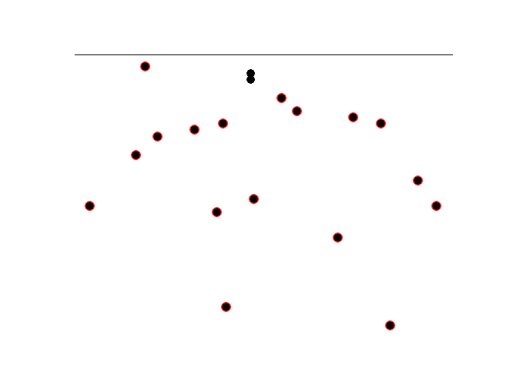

In [81]:
# Setup SimpleBlobDetector parameters.
params = cv2.SimpleBlobDetector_Params()

# Filter by Circularity
params.filterByCircularity = True
params.minCircularity = 0.8

params.filterByArea = True
params.minArea = 10
params.maxArea = 2000

# Create a detector with the parameters
detector = cv2.SimpleBlobDetector_create(params)
    
# Detect blobs.
keypoints = detector.detect(gray_Dots)

imageABC = image_with_border.copy()
imageABC = cv2.drawKeypoints(imageABC, keypoints, None, (255,0,0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.imshow(imageABC)
plt.axis('off')
plt.show()

In [82]:
keypoints[0].pt[0]

493.0

In [83]:
abcImge = image_with_border.copy()

edges = cv2.Canny(img_prewitt2, 50, 150, apertureSize=3)

lines = cv2.HoughLines(edges, 1, np.pi/180, 200)  


if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))

        cv2.line(abcImge, (x1, y1), (x2, y2), (0, 0, 255), 2)
        
# Show the result
cv2.imshow('Detected Lines', abcImge)
cv2.waitKey(0)
cv2.destroyAllWindows()

NameError: name 'img_prewitt2' is not defined

In [84]:
prewittlines2 = image_with_border.copy()

linesP = cv2.HoughLinesP(img_prewitt2, 1, np.pi/180, 50, minLineLength=20, maxLineGap=10)

horizontal_lines = []

if linesP is not None:
    for line in linesP:
        x1, y1, x2, y2 = line[0]
        angle = np.arctan2(y2 - y1, x2 - x1) * 180.0 / np.pi
        
        # if (x1 > yAxisCord and x2 > yAxisCord) and (y1 < xAxisCord and y2 < xAxisCord):
        #     if abs(angle) < 3 or abs(angle) > 177:
        cv2.line(prewittlines2, (x1, y1), (x2, y2), (0, 0, 255), 2)
        horizontal_lines.append([x1, y1, x2, y2]) 
                
prewittlines2 = cv2.cvtColor(prewittlines2, cv2.COLOR_BGR2RGB)
plt.imshow(prewittlines2)
plt.title('Detected Lines with Prewitt Operator')
plt.axis('off')
plt.show()

NameError: name 'img_prewitt2' is not defined

In [85]:
def merge_close_lines(lines, delta):
    if not lines:
        return []

    lines_sorted = sorted(lines, key=lambda line: line[0])
    
    merged_lines = []
    temp_line_group = [lines_sorted[0]]

    for current_line in lines_sorted[1:]:
        last_line_in_group = temp_line_group[-1]
        if abs(current_line[0] - last_line_in_group[0]) <= delta or abs(current_line[2] - last_line_in_group[2]) <= delta:
            temp_line_group.append(current_line)
        else:
            avg_line = np.mean(temp_line_group, axis=0).astype(int)
            merged_lines.append(avg_line)
            temp_line_group = [current_line]

    if temp_line_group:
        avg_line = np.mean(temp_line_group, axis=0).astype(int)
        merged_lines.append(avg_line)

    return merged_lines

In [86]:
prewittlines3 = image_with_border.copy()

merged_lines = merge_close_lines(horizontal_lines, delta=3)
l=0
for line in merged_lines:
    l+=1
    x1, y1, x2, y2 = line
    cv2.line(prewittlines3, (x1, y1), (x2, y2), (0, 200, 230), 3)

prewittlines3 = cv2.cvtColor(prewittlines3, cv2.COLOR_BGR2RGB)
plt.imshow(prewittlines3)
plt.title('Merged Vertical Lines')
plt.axis('off')
plt.show()

NameError: name 'horizontal_lines' is not defined

In [96]:
def find_intersection(line1_start, line1_end, line2_start, line2_end):
    x1, y1 = line1_start
    x2, y2 = line1_end
    
    x3, y3 = line2_start
    x4, y4 = line2_end
    
    # Calculate coefficients for the equations of the lines
    a1 = y2 - y1
    b1 = x1 - x2
    c1 = a1 * x1 + b1 * y1
    
    a2 = y4 - y3
    b2 = x3 - x4
    c2 = a2 * x3 + b2 * y3
    
    # Calculate determinant
    determinant = a1 * b2 - a2 * b1
    
    if determinant == 0:
        # Lines are parallel, so no intersection
        return None
    
    # Calculate intersection point
    x_intersect = (b2 * c1 - b1 * c2) / determinant
    y_intersect = (a1 * c2 - a2 * c1) / determinant
    
    return (x_intersect, y_intersect)

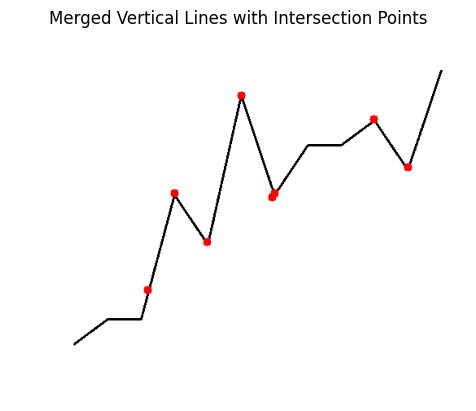

In [97]:
prewittlines4 = image_with_border.copy()

intersection_points = []

for i in range(len(merged_lines) - 1):
    line1 = merged_lines[i]
    line2 = merged_lines[i + 1]
    
    intersection_point = find_intersection((line1[0], line1[1]), (line1[2], line1[3]), 
                                           (line2[0], line2[1]), (line2[2], line2[3]))
    if intersection_point:
        intersection_points.append(intersection_point)

for point in intersection_points:
    x, y = point
    cv2.circle(prewittlines4, (int(x), int(y)), 5, (255, 0, 0), -1)

# Display the image with intersection points
plt.imshow(prewittlines4)
plt.title('Merged Vertical Lines with Intersection Points')
plt.axis('off')
plt.show()

In [98]:
def overlay_images(background_img, overlay_img):
    combined_image = cv2.addWeighted(background_img, 0.5, overlay_img, 0.5, 0)
    return combined_image

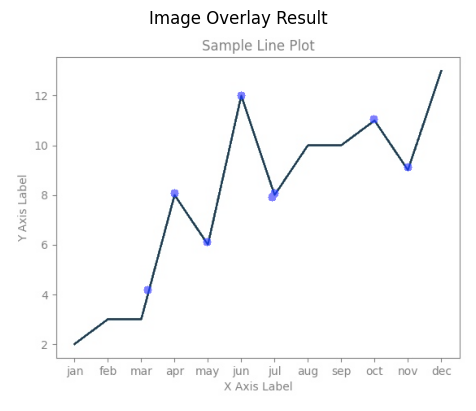

In [99]:
combined_image = overlay_images(image, prewittlines4)

# Display the result
plt.imshow(cv2.cvtColor(combined_image, cv2.COLOR_BGR2RGB))
plt.title("Image Overlay Result")
plt.axis('off')
plt.show()

Sol 01

In [100]:
def merge_close_points(points, threshold):
    if not points:
        return []

    # Sort points based on x, then y (to make sure points are sequentially checked in a logical order)
    points.sort(key=lambda x: (x[0], x[1]))
    merged_points = [points[0]]

    for current in points[1:]:
        last = merged_points[-1]
        if np.sqrt((current[0] - last[0])**2 + (current[1] - last[1])**2) <= threshold:
            # Merge points by averaging their coordinates
            merged_point = ((current[0] + last[0]) / 2, (current[1] + last[1]) / 2)
            merged_points[-1] = merged_point  # Update the last point in the list
        else:
            merged_points.append(current)

    return merged_points

In [101]:
x_coords = x_label['x_center'].values
differences = np.diff(x_coords)

average_difference = np.mean(differences)
average_difference

41.04545454545455

<function matplotlib.pyplot.show(close=None, block=None)>

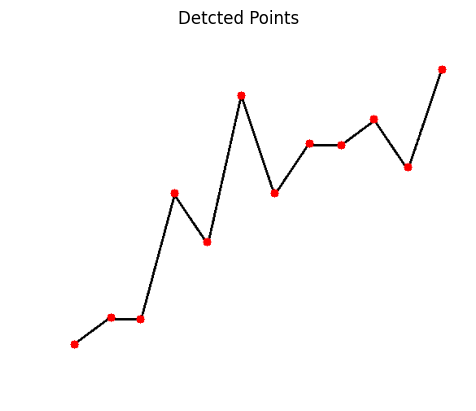

In [102]:
prewittlines45 = image_with_border.copy()

intersection_points01 = []

line1 = merged_lines[0]
intersection_points01.append((line1[0], line1[1]))

for i in range(len(merged_lines) - 1):
    line1 = merged_lines[i]
    line2 = merged_lines[i + 1]
    
    if abs(line1[0] - line2[0]) < average_difference + 1:
        intersection_point = find_intersection((line1[0], line1[1]), (line1[2], line1[3]), 
                                           (line2[0], line2[1]), (line2[2], line2[3]))
        if intersection_point:
            intersection_points01.append(intersection_point)
    else:
        intersection_points01.append((line1[2], line1[3]))
        intersection_points01.append((line2[0], line2[1]))
        
line1 = merged_lines[-1]
intersection_points01.append((line1[2], line1[3]))

merged_intersection_points = merge_close_points(intersection_points01, threshold=5)

for point in merged_intersection_points:
    x, y = point
    cv2.circle(prewittlines45, (int(x), int(y)), 5, (255, 0, 0), -1)

plt.imshow(prewittlines45)
plt.title('Detcted Points')
plt.axis('off')
plt.show

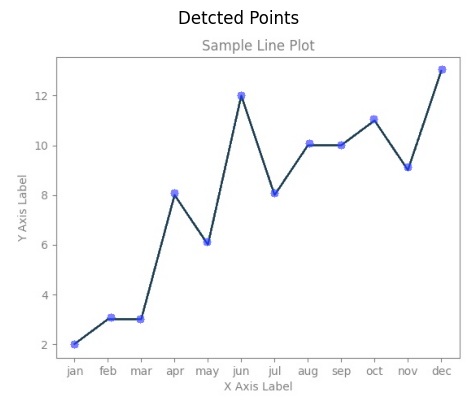

In [103]:
combined_image1 = overlay_images(prewittlines45, image)

# Display the result
plt.imshow(cv2.cvtColor(combined_image1, cv2.COLOR_BGR2RGB))
plt.title("Detcted Points")
plt.axis('off')
plt.show()

In [104]:
merged_intersection_points

[(79, 385),
 (124, 352),
 (160, 354),
 (202.0, 199.0),
 (242.42914979757086, 259.17361830336125),
 (284.59355018070613, 79.72977481234362),
 (325.6793893129771, 199.46564885496184),
 (368, 138),
 (407, 140),
 (447.8906083244397, 108.8452508004269),
 (489.23279707989724, 167.32932269839125),
 (531, 47)]

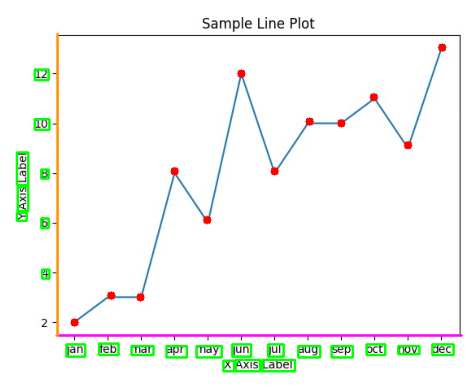

In [105]:
for point in merged_intersection_points:
    x, y = point
    cv2.circle(image1223, (int(x), int(y)), 5, (255, 0, 0), -1)
    
plt.imshow(image1223)
plt.axis('off')
plt.show()

In [106]:
xAxisCord

401.0

In [107]:
pointValues = []

for point in merged_intersection_points:
    x1, y1  = point
    
    finalVal = abs(y1 - fromCal)*vpp + toAdd
    pointValues.append(finalVal)
    
pointValues

[5.943145373255656,
 4.865434493971007,
 4.930750304836743,
 8.131225037257824,
 6.166080701153147,
 12.026340772393198,
 8.116017920987556,
 10.123357268662783,
 10.058041457797046,
 11.07549031094143,
 9.165523021568646,
 13.095226663053786]

In [108]:
values

[2, 3, 3, 8, 6, 12, 8, 10, 10, 11, 9, 13]

In [167]:
mapped_values = []

for indx in range(len(pointValues)):
    mapped_values.append({xtitle: x_labels[indx], ytitle: pointValues[indx]})
            

# Convert the list of dictionaries to a DataFrame
final = pd.DataFrame(mapped_values)
final

,x axis label,y axis label
0,jan,2.048987
1,feb,3.126698
2,mar,3.061382
3,apr,8.123357
4,may,6.158213
5,jun,12.018473
6,jul,8.108150
7,aug,10.115490
8,sep,10.050174
9,oct,11.067623


In [168]:
final['actuals'] = values
final

,x axis label,y axis label,actuals
0,jan,2.048987,2
1,feb,3.126698,3
2,mar,3.061382,3
3,apr,8.123357,8
4,may,6.158213,6
5,jun,12.018473,12
6,jul,8.108150,8
7,aug,10.115490,10
8,sep,10.050174,10
9,oct,11.067623,11


In [169]:
import sklearn.metrics
import math

mse = sklearn.metrics.mean_squared_error(final['actuals'], final[ytitle])
rmse = math.sqrt(mse)
rmse

0.10304554499610329

In [170]:
final.to_csv('ExtractedValue.csv', index=False, sep=',', encoding='utf-8')